# Séance 5 · Notebook 1 : télécharger, organiser en BIDS, nettoyer

PSY2007D — Laboratoire 1, automne 2026

<table style="width:100%; border-collapse:separate; border-spacing:0; margin:6px 0 10px 0;"><tr><td style="background:#0B2545; color:#FFFFFF; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#C9D6E8;">NOTEBOOK 1</div><div style="font-weight:bold; font-size:1.05em; color:#FFFFFF;">Prétraitement et BIDS</div><div style="font-size:0.85em; color:#C9D6E8;">télécharger · organiser · nettoyer</div></td><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 2</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Caractéristiques</div><div style="font-size:0.85em; color:#5B6472;">ERP · spectres · temps-fréquence · 1/f · complexité · connectivité</div></td><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 3</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Apprentissage automatique</div><div style="font-size:0.85em; color:#5B6472;">décoder repos/mouvement et gauche/droite</div></td></tr></table>

Cette séance suit un jeu de données EEG réel du début à la fin : du fichier téléchargé jusqu'à un modèle qui devine, essai par essai, ce que faisait la personne. Ce premier notebook prépare les données : il les télécharge, les range selon la norme **BIDS**, puis les nettoie avec **mne-denoise**. Les fichiers qu'il produit sont lus par les notebooks 2 et 3.

| Partie | Contenu |
|---|---|
| 1 | Les données et la tâche |
| 2 | Télécharger et ouvrir un fichier EDF |
| 3 | Organiser les fichiers selon BIDS (`mne-bids`) |
| 4 | Relire les données depuis BIDS |
| 5 | Nettoyer avec `mne-denoise` : ZapLine, DSS, ASR |
| 6 | Enregistrer les données propres (`derivatives/`) |
| 7 | Appliquer la chaîne à tous les participants |
| 8 | Récapitulatif |

<div style="color:#1F2937; background:#F9FAFB; border:1px solid #E5E7EB; border-radius:6px; padding:8px 14px;"><b>Trois types de blocs</b><div style="margin:3px 0;"><span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> &nbsp;le code est complet : exécutez la cellule et lisez les commentaires.</div><div style="margin:3px 0;"><span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> &nbsp;complétez une ou deux lignes marquées <code>&lt;---</code>.</div><div style="margin:3px 0;"><span style="background:#7C3AED; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 3</span> &nbsp;écrivez la cellule vous-même, à partir des indices et des liens vers la documentation.</div><div style="font-size:0.9em; color:#5B6472; margin-top:4px;">Chaque exercice est suivi d'une solution repliée : essayez d'abord.</div></div>

<details><summary>Colab ou VS Code ?</summary>

- **VS Code** : ouvrir le notebook, choisir le noyau `env_meeg` (en haut à droite). Les données sont écrites dans `donnees_seance5/`, à côté des notebooks.
- **Colab** : `Fichier → Enregistrer une copie dans Drive`, puis exécuter la première cellule. Elle installe les paquets et demande l'accès à votre Google Drive : les données y sont écrites (`MyDrive/PSY2007D/donnees_seance5`), ce qui permet aux notebooks 2 et 3 de les retrouver.
- Les cellules repliées dans Colab (titre gris) contiennent du code utilitaire : il suffit de les exécuter.
</details>

In [ ]:
# ---- Installation (Colab seulement), imports et dossier des données
import sys
from pathlib import Path

DANS_COLAB = "google.colab" in sys.modules
if DANS_COLAB:
    !pip install -q mne mne-bids "mne-denoise[mne,viz]"
    from google.colab import drive
    drive.mount("/content/drive")                      # les fichiers restent dans votre Drive
    DOSSIER = Path("/content/drive/MyDrive/PSY2007D/donnees_seance5")
else:
    DOSSIER = Path("donnees_seance5")                  # à côté des notebooks

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
import mne_bids
import mne_denoise

mne.set_log_level("WARNING")                           # MNE n'affiche que les avertissements
print("MNE", mne.__version__, "| MNE-BIDS", mne_bids.__version__, "| mne-denoise", mne_denoise.__version__)
print("Dossier des données :", DOSSIER.resolve())

## 1. Les données et la tâche

**EEG Motor Movement/Imagery Dataset** (Schalk et al., 2004), diffusé par PhysioNet (Goldberger et al., 2000) : 109 volontaires, 64 électrodes, 160 échantillons par seconde, enregistrés avec le logiciel BCI2000. Chaque personne a fait 14 courts enregistrements (des *runs*) de 1 ou 2 minutes. Nous utilisons **10 personnes** et les **runs 3, 7 et 11**, où la personne ouvre et ferme réellement le poing.

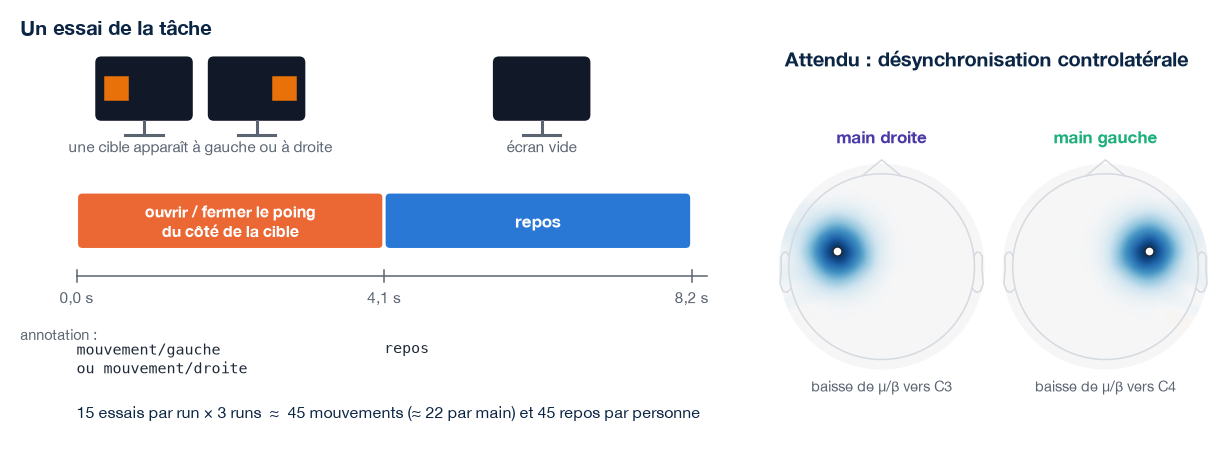

<div style="border-left:5px solid #4A3AA7; background:#F1EFFB; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#4A3AA7;">Ce que dit la littérature</b><br>Ces effets sont connus depuis longtemps ; on doit les retrouver dans les notebooks 2 et 3.<ul style='margin:4px 0 0 0;'><li><b>Désynchronisation</b> (baisse de puissance) des rythmes <b>μ (8–13 Hz)</b> et <b>β (13–30 Hz)</b> au-dessus du cortex moteur pendant le mouvement, plus marquée du côté opposé à la main (Pfurtscheller et Lopes da Silva, 1999).</li><li><b>Rebond β</b> juste après la fin du mouvement (Pfurtscheller et al., 1996).</li><li>Une <b>onde négative au-dessus du cortex moteur opposé à la main</b> qui bouge (potentiel de préparation latéralisé ; Coles, 1989).</li><li>Une <b>réponse visuelle</b> à l'apparition de la cible, plus grande du côté opposé à la cible (Luck, 2014).</li></ul></div>

<div style="border-left:5px solid #5B6472; background:#F3F4F6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#5B6472;">Données</b><br>10 personnes × 3 runs × environ 2,5 Mo : <b>environ 75 Mo</b> à télécharger. Ce sont des données publiques de démonstration, pas les données du projet. Enregistrées aux États-Unis : le bruit du secteur électrique est à <b>60 Hz</b>.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Paramètres de la séance

Ces variables sont réutilisées partout dans le notebook. Sur un ordinateur lent, gardez 3 personnes : `SUJETS = [1, 2, 3]`.

In [ ]:
# ---- Paramètres de la séance
SUJETS = list(range(1, 11))       # S001 à S010 (sur un ordinateur lent : [1, 2, 3])
RUNS = [3, 7, 11]                 # les trois runs « ouvrir/fermer le poing gauche ou droit »
TACHE = "mouvement"               # nom de la tâche dans BIDS
DOSSIER_SOURCE = DOSSIER / "sourcedata" / "eegbci"     # fichiers d'origine, non modifiés

## 2. Télécharger et ouvrir un fichier EDF

<div style="border-left:5px solid #0F766E; background:#E7F5F2; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0F766E;">Nouveau paquet : pooch</b><br><b>pooch</b> télécharge un fichier une seule fois, le range dans un dossier et vérifie qu'il est intact grâce à sa <i>somme de contrôle</i> (une empreinte unique du fichier). MNE l'utilise pour tous ses jeux de données. <a href='https://www.fatiando.org/pooch/latest/'>Documentation</a></div>

Le site de PhysioNet est lent quand toute une classe télécharge en même temps. Une copie exacte des fichiers est hébergée sur Amazon S3 ; la fonction ci-dessous essaie d'abord cette copie, puis PhysioNet.

<details><summary>Et <code>mne.datasets.eegbci.load_data</code> ?</summary>

MNE fournit `mne.datasets.eegbci.load_data(sujets, runs)`, qui télécharge les mêmes fichiers directement depuis PhysioNet. Le résultat est identique ; seule la vitesse change.
</details>

In [ ]:
#@title Fonction de téléchargement (exécuter ; pas besoin de lire le code)
from concurrent.futures import ThreadPoolExecutor
from importlib.resources import files
import pooch

MIROIR = "https://physionet-open.s3.amazonaws.com/eegmmidb/1.0.0/"   # copie de PhysioNet (rapide)
PHYSIONET = "https://physionet.org/files/eegmmidb/1.0.0/"           # site d'origine (lent)


def telecharger_eegbci(sujets, runs, dossier, n_parallele=10):
    """Télécharge les fichiers EDF et renvoie leurs chemins (S001/S001R03.edf, ...)."""
    lignes = files("mne").joinpath("data", "eegbci_checksums.txt").read_text().splitlines()
    registre = dict(ligne.split()[:2] for ligne in lignes if ligne.strip())   # sommes de contrôle
    dossier = Path(dossier)

    def un_fichier(nom):
        cible = dossier / nom
        if cible.exists():                         # déjà téléchargé
            return cible
        erreur = None
        for base in (MIROIR, PHYSIONET):
            try:
                pooch.retrieve(base + nom, known_hash=registre.get(nom), fname=cible.name,
                               path=cible.parent, progressbar=False)
                return cible
            except Exception as err:               # serveur indisponible : essayer le suivant
                erreur = err
        raise erreur

    noms = [f"S{s:03d}/S{s:03d}R{r:02d}.edf" for s in sujets for r in runs]
    with ThreadPoolExecutor(n_parallele) as pool:  # plusieurs fichiers à la fois
        return list(pool.map(un_fichier, noms))

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Télécharger

Environ une minute la première fois ; quelques millisecondes ensuite (les fichiers sont déjà là).

In [ ]:
# ---- Télécharger les fichiers EDF
import time

debut = time.time()
chemins_edf = telecharger_eegbci(SUJETS, RUNS, DOSSIER_SOURCE)
print(len(chemins_edf), "fichiers en %.0f s" % (time.time() - debut))
print("Premier fichier :", chemins_edf[0])

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Ouvrir un fichier EDF

**EDF** (*European Data Format*) est un format courant pour l'EEG : un en-tête (noms des canaux, fréquence d'échantillonnage, ...) suivi des données. `mne.io.read_raw_edf` le lit et renvoie un objet `Raw`, comme à la séance 4. Avec `preload=False`, MNE lit l'en-tête tout de suite et les données seulement quand on en a besoin.

In [ ]:
# ---- Lire le premier run du premier participant
raw_edf = mne.io.read_raw_edf(chemins_edf[0], preload=False)
print(raw_edf)
print("Fréquence d'échantillonnage :", raw_edf.info["sfreq"], "Hz")
print("Premiers canaux :", raw_edf.ch_names[:6])
print("Annotations :", raw_edf.annotations.count())

Trois choses ne vont pas :

1. Les noms des canaux ne suivent pas la norme (`Fc5.` au lieu de `FC5`) : MNE ne peut pas placer les électrodes sur la tête.
2. Le fichier ne contient pas la position des électrodes.
3. Les événements s'appellent `T0`, `T1`, `T2` : il faut lire la documentation pour savoir que `T1` veut dire « poing gauche ».

On corrige les trois avant de ranger le fichier.

In [ ]:
# ---- Trois corrections : noms des canaux, positions, noms des événements
from mne.datasets import eegbci

eegbci.standardize(raw_edf)                    # "Fc5." -> "FC5", "Fp1." -> "Fp1", ...
raw_edf.set_montage("colin27_1005")            # positions standard (système 10-05, tête modèle Colin27)
raw_edf.annotations.rename({"T0": "repos", "T1": "mouvement/gauche", "T2": "mouvement/droite"})

print("Canaux :", raw_edf.ch_names[:6])
print("Annotations :", raw_edf.annotations.count())
raw_edf.plot_sensors(show_names=["Fp1", "Fp2", "F7", "F8", "C3", "Cz", "C4", "O1", "O2"]);

<details><summary>Pourquoi <code>mouvement/gauche</code> avec une barre oblique ?</summary>

MNE lit la barre oblique comme une hiérarchie : `epochs["mouvement"]` sélectionnera les deux mains d'un coup, `epochs["gauche"]` seulement la main gauche. Même principe que `mot/freq_faible` à la séance 4.
</details>

In [ ]:
# ---- 10 secondes de signal brut (les bandes de couleur sont les annotations)
raw_edf.plot(start=20, duration=10, n_channels=16, scalings=dict(eeg=100e-6));

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> À vous de compléter

1. Durée du run en secondes (`raw_edf.times` contient le temps de chaque échantillon).
2. Nombre d'échantillons (`raw_edf.n_times`). Vérifiez : durée × fréquence d'échantillonnage ≈ nombre d'échantillons.

In [ ]:
# ---- Exercice
# duree = ...                                    # <--- à compléter (dernier élément de raw_edf.times)
# n = ...                                        # <--- à compléter
# print(duree, n, duree * raw_edf.info["sfreq"])

In [ ]:
#@title Solution (à consulter après avoir essayé)
duree = raw_edf.times[-1]
n = raw_edf.n_times
print("Durée : %.1f s | échantillons : %d | durée × sfreq : %.0f" % (duree, n, duree * raw_edf.info["sfreq"]))

## 3. Organiser les fichiers selon BIDS

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Notion : BIDS</b><br><b>BIDS</b> (<i>Brain Imaging Data Structure</i>) est une convention pour nommer et ranger les fichiers de neuroimagerie (Gorgolewski et al., 2016 ; pour l'EEG : Pernet et al., 2019). Tout le monde range de la même façon : un collègue, un logiciel ou vous-même dans six mois retrouvez les fichiers sans explication. Chaque enregistrement est accompagné de petits fichiers texte (tableaux <code>.tsv</code>, fichiers <code>.json</code>) qui décrivent les canaux, les événements et l'appareil.</div>

Le nom d'un fichier BIDS est une suite de paires `clé-valeur` séparées par `_` :

<div style="font-family:Menlo,Consolas,monospace; font-size:1.05em; color:#1F2937; background:#F9FAFB; border:1px solid #E5E7EB; border-radius:6px; padding:12px 14px; margin:6px 0;">
<span style="background:#DBEAFE; padding:2px 4px; border-radius:3px;">sub-001</span>_<span style="background:#FDE7D3; padding:2px 4px; border-radius:3px;">task-mouvement</span>_<span style="background:#E7F5F2; padding:2px 4px; border-radius:3px;">run-03</span>_<span style="background:#EDE9FE; padding:2px 4px; border-radius:3px;">eeg</span><span style="background:#F3F4F6; padding:2px 4px; border-radius:3px;">.edf</span>
<div style="font-family:Helvetica,Arial,sans-serif; font-size:0.85em; color:#5B6472; margin-top:8px;">
<span style="background:#DBEAFE; padding:1px 4px;">participant</span> &nbsp; <span style="background:#FDE7D3; padding:1px 4px;">tâche</span> &nbsp; <span style="background:#E7F5F2; padding:1px 4px;">run</span> &nbsp; <span style="background:#EDE9FE; padding:1px 4px;">type de données (suffixe)</span> &nbsp; <span style="background:#F3F4F6; padding:1px 4px;">format</span>
</div></div>

<div style="border-left:5px solid #0F766E; background:#E7F5F2; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0F766E;">Nouveau paquet : mne-bids</b><br><b>MNE-BIDS</b> écrit et lit des données au format BIDS à partir d'objets MNE (Appelhoff et al., 2019). <code>BIDSPath</code> construit les noms de fichiers ; <code>write_raw_bids</code> écrit ; <code>read_raw_bids</code> relit. <a href='https://mne.tools/mne-bids/stable/index.html'>Documentation</a></div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Écrire un run dans BIDS

`BIDSPath` ne crée aucun fichier : il fabrique le nom et le chemin à partir des entités. `write_raw_bids` copie ensuite le fichier EDF (sans modifier les données) et écrit les fichiers d'accompagnement.

In [ ]:
# ---- Un chemin BIDS : participant, tâche, run, type de données, dossier racine
from mne_bids import BIDSPath, write_raw_bids

EVENT_ID = {"repos": 1, "mouvement/gauche": 2, "mouvement/droite": 3}   # code numérique de chaque événement

chemin_bids = BIDSPath(subject="001", task=TACHE, run="03", datatype="eeg", root=DOSSIER)
print("Nom  :", chemin_bids.basename)
print("Dossier :", chemin_bids.directory)

In [ ]:
# ---- Écrire
raw_edf.info["line_freq"] = 60                  # fréquence du secteur : obligatoire dans BIDS
write_raw_bids(raw_edf, chemin_bids, event_id=EVENT_ID, overwrite=True, verbose=False)
print("Écrit :", chemin_bids.fpath)

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Tous les runs de tous les participants

On regroupe les étapes dans une fonction et on l'appelle pour chaque fichier. Le numéro du participant et du run se lisent dans le nom du fichier : `S001R03.edf`.

In [ ]:
# ---- Une fonction pour convertir un fichier, puis une boucle sur tous les fichiers
def edf_vers_bids(chemin_edf, sujet, run, racine):
    """Lit un fichier EDF, corrige noms/positions/événements et l'écrit dans BIDS."""
    raw = mne.io.read_raw_edf(chemin_edf, preload=False, verbose=False)
    eegbci.standardize(raw)
    raw.set_montage("colin27_1005")
    raw.annotations.rename({"T0": "repos", "T1": "mouvement/gauche", "T2": "mouvement/droite"})
    raw.info["line_freq"] = 60
    chemin = BIDSPath(subject=f"{sujet:03d}", task=TACHE, run=f"{run:02d}", datatype="eeg", root=racine)
    write_raw_bids(raw, chemin, event_id=EVENT_ID, overwrite=True, verbose=False)
    return chemin


for chemin_edf in chemins_edf:
    sujet = int(chemin_edf.name[1:4])            # "S001R03.edf" -> 1
    run = int(chemin_edf.name[5:7])              # "S001R03.edf" -> 3
    edf_vers_bids(chemin_edf, sujet, run, DOSSIER)
print(len(chemins_edf), "runs écrits dans", DOSSIER)

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Ce que BIDS a produit

À la racine : la description du jeu de données et la liste des participants. Dans chaque `sub-XXX/eeg/` : les données (`_eeg.edf`) et, pour chaque run, les canaux (`_channels.tsv`), les événements (`_events.tsv`) et l'appareil (`_eeg.json`).

In [ ]:
# ---- L'arborescence : la racine, puis le dossier d'un participant
from mne_bids import print_dir_tree

print_dir_tree(DOSSIER, max_depth=1)
print()
print_dir_tree(DOSSIER / "sub-001")

In [ ]:
# ---- Les fichiers d'accompagnement sont de simples tableaux : pandas les lit directement
chemin_evenements = chemin_bids.copy().update(suffix="events", extension=".tsv")
evenements = pd.read_csv(chemin_evenements.fpath, sep="\t")
evenements.head(6)

Le fichier `dataset_description.json` de la racine décrit le jeu de données. MNE-BIDS l'a créé avec des champs vides ; on le complète : nom, auteurs, licence, références.

In [ ]:
# ---- Compléter la description du jeu de données
from mne_bids import make_dataset_description, make_report

make_dataset_description(
    path=DOSSIER,
    name="EEG Motor Movement/Imagery Dataset (sous-ensemble PSY2007D)",
    authors=["Gerwin Schalk", "Dennis J. McFarland", "Thilo Hinterberger", "Niels Birbaumer", "Jonathan R. Wolpaw"],
    data_license="ODC-By-1.0",
    references_and_links=["https://physionet.org/content/eegmmidb/1.0.0/",
                          "Schalk et al. (2004). IEEE Transactions on Biomedical Engineering, 51(6), 1034-1043."],
    overwrite=True, verbose=False)

# Un résumé du jeu de données, rédigé automatiquement à partir des fichiers BIDS
print(make_report(DOSSIER, verbose=False))

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> À vous de compléter

1. Lisez le tableau des **canaux** (`suffix="channels"`) du run 07 de `sub-002`. Indice : copiez `chemin_bids` et changez `subject`, `run`, `suffix`, `extension` avec `.update(...)`.
2. Combien d'essais `repos` contient le tableau `evenements` ? (`evenements["trial_type"].value_counts()`)

In [ ]:
# ---- Exercice
# chemin_canaux = chemin_bids.copy().update(subject=..., run=..., suffix=..., extension=...)   # <--- à compléter
# canaux = pd.read_csv(chemin_canaux.fpath, sep="\t")
# canaux.head()
# print(...)                                                                                 # <--- à compléter

In [ ]:
#@title Solution (à consulter après avoir essayé)
chemin_canaux = chemin_bids.copy().update(subject="002", run="07", suffix="channels", extension=".tsv")
canaux = pd.read_csv(chemin_canaux.fpath, sep="\t")
display(canaux.head())
print(evenements["trial_type"].value_counts())

### <span style="background:#7C3AED; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 3</span> À vous de construire : chercher des fichiers dans BIDS

Objectif : obtenir la liste de **tous les fichiers de données du run 11**, pour tous les participants, sans écrire les noms à la main.

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Indices</b><br><ul style='margin:0;'><li>La fonction <code>find_matching_paths</code> de <code>mne_bids</code> cherche les fichiers dont les entités correspondent : <code>find_matching_paths(DOSSIER, runs=..., suffixes=..., extensions=...)</code>.</li><li>Le run s'écrit comme dans les noms de fichiers : <code>"11"</code>. Les données ont le suffixe <code>"eeg"</code> et l'extension <code>".edf"</code>.</li><li>Le résultat est une liste de <code>BIDSPath</code> ; <code>len(...)</code> doit valoir le nombre de participants.</li><li>Documentation : <a href='https://mne.tools/mne-bids/stable/generated/mne_bids.find_matching_paths.html'>find_matching_paths</a>, <a href='https://mne.tools/mne-bids/stable/generated/mne_bids.BIDSPath.html'>BIDSPath</a>.</li></ul></div>

In [ ]:
# ---- Votre cellule

In [ ]:
#@title Solution (à consulter après avoir essayé)
from mne_bids import find_matching_paths

run11 = find_matching_paths(DOSSIER, runs="11", suffixes="eeg", extensions=".edf")
print(len(run11), "fichiers")
for chemin in run11[:3]:
    print(chemin.basename)

## 4. Relire les données depuis BIDS

`read_raw_bids` lit les données **et** les fichiers d'accompagnement : les événements deviennent des annotations, les positions des électrodes sont chargées, la fréquence du secteur est connue. On lit les trois runs d'une personne et on les met bout à bout.

Pour la démonstration du nettoyage, on prend **S007** : le bruit du secteur y est particulièrement fort.

<details><summary>Pourquoi <code>on_ch_mismatch="rename"</code> ?</summary>

`write_raw_bids` a copié le fichier EDF tel quel : à l'intérieur, les canaux s'appellent encore `Fc5.`. Le fichier `channels.tsv`, lui, contient les noms corrigés. L'option `"rename"` dit à MNE-BIDS d'utiliser les noms de `channels.tsv`, qui font foi.
</details>

In [ ]:
# ---- Lire les trois runs d'un participant et les mettre bout à bout
from mne_bids import read_raw_bids


def charger_bids(racine, sujet):
    """Lit les trois runs d'un participant dans BIDS et les met bout à bout."""
    raws = []
    for run in RUNS:
        chemin = BIDSPath(subject=f"{sujet:03d}", task=TACHE, run=f"{run:02d}", datatype="eeg", root=racine)
        raws.append(read_raw_bids(chemin, on_ch_mismatch="rename", verbose=False).load_data())
    return mne.concatenate_raws(raws)


SUJET_DEMO = 7
raw = charger_bids(DOSSIER, SUJET_DEMO)
print(raw)
print("Durée : %.0f s" % raw.times[-1], "| secteur :", raw.info["line_freq"], "Hz")
print("Annotations :", raw.annotations.count())

Les annotations `BAD boundary` et `EDGE boundary` marquent les jonctions entre runs. Plus tard, MNE écartera automatiquement les essais qui chevauchent une jonction.

## 5. Nettoyer avec mne-denoise

L'EEG enregistre l'activité du cerveau, mais aussi celle des yeux, des muscles, du réseau électrique. Ces signaux parasites sont des **artefacts**. La chaîne de nettoyage de la séance :

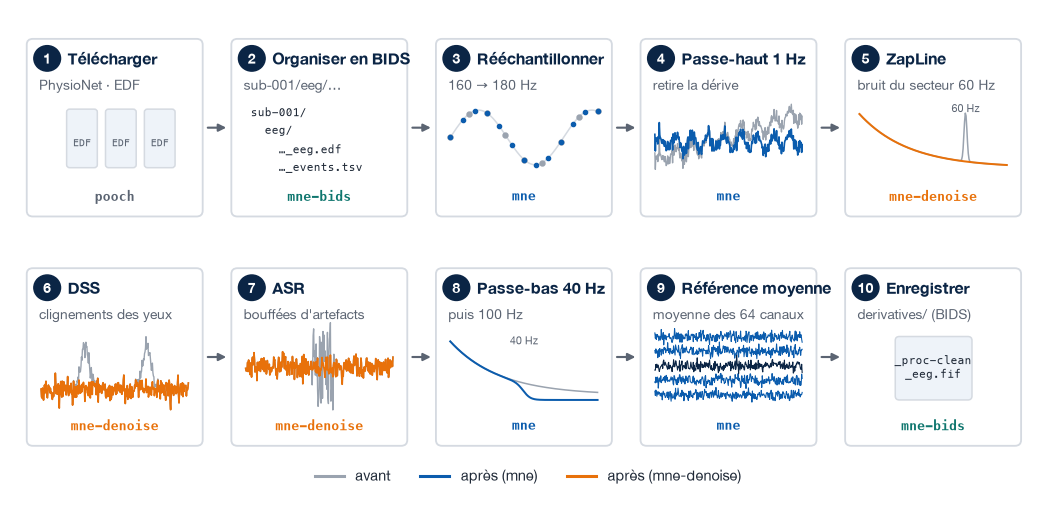

<div style="border-left:5px solid #0F766E; background:#E7F5F2; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0F766E;">Nouveau paquet : mne-denoise</b><br><b>mne-denoise</b> regroupe des méthodes de nettoyage de l'EEG et de la MEG qui acceptent directement les objets MNE (<code>Raw</code>, <code>Epochs</code>) : ZapLine pour le bruit du secteur, DSS pour les artefacts qui se répètent, ASR pour les bouffées d'artefacts, et d'autres. Chaque méthode s'utilise comme un modèle de scikit-learn : on crée l'objet, puis <code>fit_transform(raw)</code> renvoie une copie nettoyée. Paquet de l'écosystème MNE, développé en partie à l'Université de Montréal. <a href='https://mne.tools/mne-denoise/stable/'>Documentation</a></div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Regarder avant de nettoyer

Deux artefacts sautent aux yeux : un **pic étroit à 60 Hz** dans le spectre (le secteur électrique) et de grandes ondes sur **Fp1 et Fp2**, les électrodes juste au-dessus des yeux (les clignements).

In [ ]:
# ---- Spectre de chaque canal (une courbe par électrode, couleur = position)
raw.compute_psd(fmax=80).plot(amplitude=False);

In [ ]:
# ---- Les clignements : grandes ondes sur Fp1 et Fp2, presque absentes à l'arrière (Oz)
raw.plot(start=20, duration=15, picks=["Fp1", "Fp2", "Fz", "Cz", "Pz", "Oz"], scalings=dict(eeg=150e-6));

### Étape 1 · Rééchantillonner et filtrer

- **Rééchantillonner à 180 Hz.** ZapLine (étape 2) repère le bruit du secteur par sa période : à 60 Hz, un cycle dure 1/60 s. À 160 Hz, cela fait 2,67 échantillons, un nombre non entier ; à 180 Hz, exactement 3.
- **Passe-haut à 1 Hz.** Retire les dérives lentes (transpiration, mouvements des câbles) qui gênent les étapes suivantes.

<div style="border-left:5px solid #E8710A; background:#FDF1E7; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#E8710A;">Attention</b><br>Un passe-haut à 1 Hz peut déformer les ERP lents (Tanner et al., 2015). Ici, les effets étudiés sont surtout des oscillations au-dessus de 4 Hz : c'est un compromis acceptable.</div>

<details><summary>ZapLine à 160 Hz ?</summary>

À 160 Hz, ZapLine fonctionne, mais le filtre de lissage qu'il utilise ne tombe pas exactement sur le cycle du secteur : sur ces données, il retire environ 17 dB du pic, contre plus de 35 dB à 180 Hz. Rééchantillonner avant ZapLine règle le problème sans coût notable.
</details>

In [ ]:
# ---- Étape 1 : 180 Hz, puis passe-haut à 1 Hz (sur une copie : raw reste intact)
raw_etape1 = raw.copy().resample(180.0).filter(l_freq=1.0, h_freq=None)
print("Fréquence :", raw_etape1.info["sfreq"], "Hz | passe-haut :", raw_etape1.info["highpass"], "Hz")

### Étape 2 · ZapLine : le bruit du secteur

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Notion : ZapLine</b><br>Un filtre coupe-bande (<code>notch_filter</code>, séance 4) retire une bande de fréquences sur <b>tous</b> les canaux, cerveau compris. ZapLine (de Cheveigné, 2020) procède autrement : il cherche les <b>combinaisons de canaux</b> (des composantes) dont le signal est dominé par 60 Hz, et retire seulement ces composantes. C'est une application de la <b>DSS</b> (<i>denoising source separation</i>), la même méthode que l'étape 3.</div>

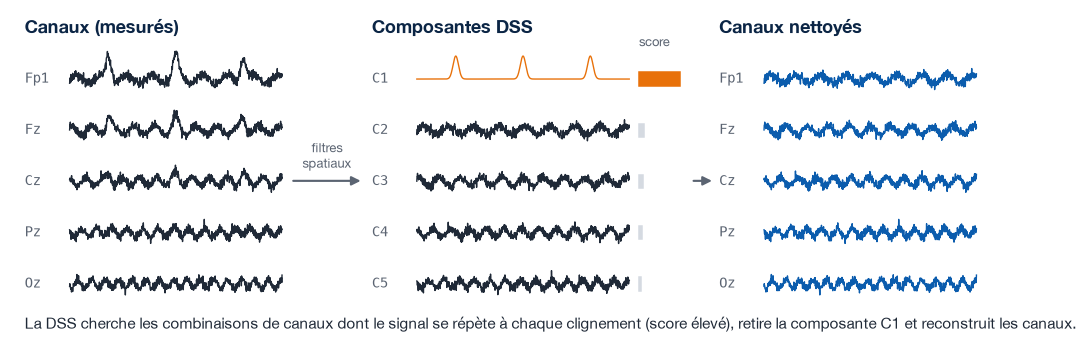

In [ ]:
# ---- Étape 2 : ZapLine
from mne_denoise.zapline import ZapLine

zapline = ZapLine(sfreq=180.0, line_freq=60.0)       # n_select="auto" : le nombre de composantes est choisi seul
raw_etape2 = zapline.fit_transform(raw_etape1)
print("Composantes retirées :", zapline.n_removed_)

In [ ]:
# ---- Contrôle : spectre moyen avant / après (figure de mne-denoise)
from mne_denoise import viz

viz.plot_psd_comparison(raw_etape1, raw_etape2, fmin=1, fmax=89, line_freq=60.0);

Le pic à 60 Hz disparaît ; le reste du spectre ne bouge pas. Au-dessus de 80 Hz, la puissance tombe : le fichier d'origine (160 Hz) ne contient rien au-delà de 80 Hz, même après rééchantillonnage.

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> À vous de compléter : ZapLine ou filtre coupe-bande ?

1. Appliquez un filtre coupe-bande à 60 Hz sur une copie de `raw_etape1` (`.notch_filter(freqs=...)`).
2. Comparez les deux spectres entre 40 et 80 Hz. Que fait le coupe-bande autour de 60 Hz ?

In [ ]:
# ---- Exercice
# raw_coupe_bande = raw_etape1.copy().notch_filter(freqs=...)                     # <--- à compléter
# viz.plot_psd_comparison(raw_etape1, raw_coupe_bande, fmin=40, fmax=80, line_freq=60.0);
# viz.plot_psd_comparison(raw_etape1, raw_etape2, fmin=40, fmax=80, line_freq=60.0);

In [ ]:
#@title Solution (à consulter après avoir essayé)
raw_coupe_bande = raw_etape1.copy().notch_filter(freqs=60.0)
viz.plot_psd_comparison(raw_etape1, raw_coupe_bande, fmin=40, fmax=80, line_freq=60.0);
viz.plot_psd_comparison(raw_etape1, raw_etape2, fmin=40, fmax=80, line_freq=60.0);
# Le coupe-bande creuse un « trou » autour de 60 Hz sur tous les canaux ; ZapLine laisse le spectre continu.

### Étape 3 · DSS : les clignements des yeux

Un clignement déplace les paupières et les yeux, qui sont chargés électriquement : l'EEG enregistre une grande onde (100 µV et plus) surtout à l'avant de la tête. On procède en deux temps :

1. **Repérer** chaque clignement sur Fp1 et Fp2 (`mne.preprocessing.find_eog_events`).
2. **DSS** : chercher la composante qui se répète le plus d'un clignement à l'autre (le *biais* `CycleAverageBias` fait la moyenne autour de chaque clignement), puis la **retirer** (`component_action="subtract"`).

In [ ]:
# ---- Étape 3a : repérer les clignements
clignements = mne.preprocessing.find_eog_events(raw_etape2, ch_name=["Fp1", "Fp2"])
print(len(clignements), "clignements en %.0f s" % raw_etape2.times[-1])

# Le clignement moyen et sa topographie : maximal à l'avant
epochs_clignements = mne.preprocessing.create_eog_epochs(raw_etape2, ch_name=["Fp1", "Fp2"])
epochs_clignements.average().plot_joint(times=[0.0], title="Clignement moyen");

In [ ]:
# ---- Étape 3b : DSS centrée sur les clignements, puis retrait de la première composante
from mne_denoise.dss import DSS, CycleAverageBias

sf = raw_etape2.info["sfreq"]
echantillons = clignements[:, 0] - raw_etape2.first_samp          # position de chaque clignement
marge = int(0.5 * sf)                                              # on écarte les clignements trop près des bords
echantillons = echantillons[(echantillons > marge) & (echantillons < raw_etape2.n_times - marge)]

biais = CycleAverageBias(echantillons, window=(-0.4, 0.4), window_unit="seconds", sfreq=sf)
dss = DSS(bias=biais, n_select=1, component_action="subtract")    # retirer 1 composante
raw_etape3 = dss.fit_transform(raw_etape2)

In [ ]:
# ---- Contrôle : score des composantes et topographie de la composante retirée
fig, axes = plt.subplots(1, 2, figsize=(9, 3), gridspec_kw=dict(width_ratios=[1.6, 1]))
axes[0].bar(np.arange(1, 11), dss.eigenvalues_[:10], color=["#E8710A"] + ["#C3C9D2"] * 9)
axes[0].set(xlabel="composante", ylabel="score DSS", title="La composante 1 se détache")
mne.viz.plot_topomap(dss.patterns_[:, 0], raw_etape2.info, axes=axes[1], show=False)
axes[1].set_title("Composante retirée")
plt.tight_layout(); plt.show()

In [ ]:
# ---- Contrôle : Fp1 avant / après sur 20 secondes
viz.plot_signal_overlay(raw_etape2, raw_etape3, times=raw_etape2.times, pick="Fp1", start=20, stop=40,
                        scale_after=False, before_label="avant", after_label="après DSS",
                        y_label="Amplitude (V)", x_label="Temps (s)");

### Étape 4 · ASR : les bouffées d'artefacts

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Notion : ASR</b><br><b>ASR</b> (<i>artifact subspace reconstruction</i> ; Chang et al., 2020) apprend d'abord à quoi ressemblent des données propres, à partir des passages les plus calmes de l'enregistrement. Ensuite, fenêtre par fenêtre (0,5 s), si une composante dépasse <code>cutoff</code> fois son amplitude habituelle (mouvement de tête, contraction musculaire, électrode qui bouge), ASR la reconstruit à partir du reste des données. Un <code>cutoff</code> de 20 à 30 est prudent ; plus il est bas, plus ASR modifie les données.</div>

In [ ]:
# ---- Étape 4 : ASR (quelques secondes)
from mne_denoise.asr import ASR

asr = ASR(cutoff=20)
raw_etape4 = asr.fit_transform(raw_etape3)
print("Fenêtres modifiées : %.1f %%" % (100 * asr.fraction_reconstructed_windows_))
viz.plot_asr_repair_timeline(asr);

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> À vous de compléter : un ASR trop agressif

Relancez ASR avec `cutoff=5`. Quelle part des fenêtres est modifiée ? Pourquoi un nettoyage trop agressif pose-t-il problème pour étudier le cerveau ?

In [ ]:
# ---- Exercice
# asr_strict = ASR(cutoff=...)                                     # <--- à compléter
# raw_strict = asr_strict.fit_transform(raw_etape3)
# print("Fenêtres modifiées : %.1f %%" % (100 * asr_strict.fraction_reconstructed_windows_))

In [ ]:
#@title Solution (à consulter après avoir essayé)
asr_strict = ASR(cutoff=5)
raw_strict = asr_strict.fit_transform(raw_etape3)
print("Fenêtres modifiées : %.1f %%" % (100 * asr_strict.fraction_reconstructed_windows_))
# Avec cutoff=5, ASR modifie une grande partie du signal : il « répare » aussi de l'activité cérébrale ample
# (par exemple les bouffées de rythme μ), ce qui fausserait justement les mesures qui nous intéressent.

### Étape 5 · Passe-bas, 100 Hz, référence moyenne

- **Passe-bas à 40 Hz** : on étudie les rythmes sous 40 Hz ; au-dessus, il reste surtout de l'activité musculaire.
- **100 Hz** : pour représenter une fréquence, il faut au moins deux échantillons par cycle (règle de Nyquist). Sous 40 Hz, 100 échantillons par seconde suffisent, et les fichiers sont presque deux fois plus légers.
- **Référence moyenne** : chaque électrode mesure une différence de potentiel avec une électrode de référence. En soustrayant à chaque instant la moyenne des 64 électrodes, aucune électrode n'est privilégiée.

In [ ]:
# ---- Étape 5 : passe-bas 40 Hz, 100 Hz, référence moyenne
raw_propre = raw_etape4.copy().filter(l_freq=None, h_freq=40.0).resample(100.0)
raw_propre.set_eeg_reference("average")
print(raw_propre)

In [ ]:
# ---- Avant / après : les mêmes 15 secondes
for titre, r in [("Brut", raw), ("Nettoyé", raw_propre)]:
    fig = r.plot(start=20, duration=15, picks=["Fp1", "Fp2", "Fz", "C3", "Cz", "C4", "Pz", "Oz"],
                 scalings=dict(eeg=100e-6), show_scrollbars=False, title=titre)

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Toute la chaîne dans une fonction

Les cinq étapes, dans l'ordre, avec les mêmes réglages. Le dictionnaire `rapport` garde quelques chiffres de contrôle pour chaque personne.

In [ ]:
# ---- La chaîne complète
def pretraiter(raw, rapport=None):
    """Chaîne de prétraitement de la séance (mne + mne-denoise). Renvoie une copie nettoyée."""
    raw = raw.copy().load_data()
    raw.resample(180.0)                                    # 180 / 60 = 3 échantillons par cycle
    raw.filter(l_freq=1.0, h_freq=None)                    # retire la dérive lente
    zapline = ZapLine(sfreq=180.0, line_freq=60.0)
    raw = zapline.fit_transform(raw)                       # bruit du secteur

    clignements = mne.preprocessing.find_eog_events(raw, ch_name=["Fp1", "Fp2"], verbose=False)
    echantillons = clignements[:, 0] - raw.first_samp
    marge = int(0.5 * raw.info["sfreq"])
    echantillons = echantillons[(echantillons > marge) & (echantillons < raw.n_times - marge)]
    if len(echantillons) >= 5:                             # assez de clignements pour la DSS
        biais = CycleAverageBias(echantillons, window=(-0.4, 0.4), window_unit="seconds",
                                 sfreq=raw.info["sfreq"])
        raw = DSS(bias=biais, n_select=1, component_action="subtract").fit_transform(raw)

    asr = ASR(cutoff=20)
    raw = asr.fit_transform(raw)                           # bouffées de grande amplitude
    raw.filter(l_freq=None, h_freq=40.0)                   # on analyse sous 40 Hz
    raw.resample(100.0)                                    # 100 Hz suffit sous 40 Hz
    raw.set_eeg_reference("average", verbose=False)

    if rapport is not None:
        rapport["zapline_composantes"] = int(zapline.n_removed_)
        rapport["clignements"] = len(echantillons)
        rapport["asr_fenetres_%"] = round(100 * asr.fraction_reconstructed_windows_, 1)
    return raw

## 6. Enregistrer les données propres

BIDS range les données transformées dans `derivatives/<nom de la chaîne>/`, avec les mêmes noms de fichiers et une entité de plus : `proc-clean` (*processing*). Les données d'origine ne sont jamais écrasées : on peut toujours refaire le nettoyage autrement.

On enregistre au format **FIF**, le format natif de MNE : il garde tout (annotations, positions, filtres appliqués).

In [ ]:
# ---- Le chemin BIDS du fichier propre d'un participant
def chemin_propre(racine, sujet):
    """BIDSPath du fichier prétraité d'un participant (dans derivatives/pretraitement)."""
    return BIDSPath(root=Path(racine) / "derivatives" / "pretraitement", subject=f"{sujet:03d}",
                    task=TACHE, processing="clean", datatype="eeg", suffix="eeg",
                    extension=".fif", check=False)


sortie = chemin_propre(DOSSIER, SUJET_DEMO)
sortie.mkdir()                                         # crée les dossiers s'ils n'existent pas
raw_propre.save(sortie.fpath, overwrite=True)
print(sortie.fpath)

In [ ]:
# ---- Décrire la chaîne : un fichier dataset_description.json dans derivatives/pretraitement
make_dataset_description(path=DOSSIER / "derivatives" / "pretraitement",
                         name="PSY2007D séance 5 : prétraitement", dataset_type="derivative",
                         authors=["PSY2007D"],
                         generated_by=[{"Name": "mne-denoise", "Version": mne_denoise.__version__},
                                       {"Name": "MNE-Python", "Version": mne.__version__}],
                         overwrite=True, verbose=False)
print((DOSSIER / "derivatives" / "pretraitement" / "dataset_description.json").read_text())

In [ ]:
# ---- Relire et vérifier
raw_relu = mne.io.read_raw_fif(sortie.fpath, preload=True)
print(raw_relu)
print("Mêmes données :", np.allclose(raw_relu.get_data(), raw_propre.get_data(), rtol=1e-5, atol=1e-12))
print("Mêmes annotations :", raw_relu.annotations.count() == raw_propre.annotations.count())

## 7. Tous les participants

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> La boucle

Environ 5 à 10 secondes par personne. Les personnes déjà traitées sont sautées : vous pouvez relancer la cellule sans tout refaire.

In [ ]:
# ---- Prétraiter et enregistrer chaque participant
rapports = []
for sujet in SUJETS:
    sortie = chemin_propre(DOSSIER, sujet)
    if sortie.fpath.exists():
        print(f"S{sujet:03d} : déjà fait")
        continue
    debut = time.time()
    rapport = {"sujet": sujet}
    raw_propre_s = pretraiter(charger_bids(DOSSIER, sujet), rapport)
    sortie.mkdir()
    raw_propre_s.save(sortie.fpath, overwrite=True)
    rapports.append(rapport)
    print(f"S{sujet:03d} : {time.time() - debut:.0f} s")

pd.DataFrame(rapports)

Le tableau (vide si tout était déjà fait) montre que les personnes diffèrent : certaines clignent deux fois plus que d'autres, et ASR intervient plus ou moins. C'est normal ; c'est aussi pour cela qu'on vérifie chaque personne.

### <span style="background:#7C3AED; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 3</span> À vous de construire : contrôler un participant

Objectif : pour **S005**, superposer le spectre moyen des données **brutes** (BIDS) et des données **propres** (`derivatives`), entre 1 et 45 Hz.

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Indices</b><br><ul style='margin:0;'><li>Données brutes : <code>charger_bids(DOSSIER, 5)</code>. Données propres : <code>mne.io.read_raw_fif(chemin_propre(DOSSIER, 5).fpath)</code>.</li><li>Les deux objets n'ont pas la même fréquence d'échantillonnage : <code>viz.plot_psd_comparison</code> exige des données de même forme. Calculez plutôt chaque spectre avec <code>.compute_psd(fmin=1, fmax=45)</code>, puis tracez-les sur les mêmes axes : <code>spectre.plot(average=True, amplitude=False, axes=ax, show=False)</code>.</li><li>Ou plus simple : récupérez <code>spectre.get_data()</code> et <code>spectre.freqs</code>, moyennez sur les canaux (<code>.mean(axis=0)</code>) et utilisez <code>plt.semilogy</code>.</li><li>Documentation : <a href='https://mne.tools/stable/generated/mne.io.Raw.html#mne.io.Raw.compute_psd'>Raw.compute_psd</a>, <a href='https://mne.tools/stable/generated/mne.time_frequency.Spectrum.html'>Spectrum</a>.</li></ul></div>

In [ ]:
# ---- Votre cellule

In [ ]:
#@title Solution (à consulter après avoir essayé)
brut = charger_bids(DOSSIER, 5)
propre = mne.io.read_raw_fif(chemin_propre(DOSSIER, 5).fpath)
plt.figure(figsize=(7, 3.5))
for nom, r, couleur in [("brut", brut, "#9AA3AF"), ("propre", propre, "#0B5CAD")]:
    spectre = r.compute_psd(fmin=1, fmax=45)
    plt.semilogy(spectre.freqs, spectre.get_data().mean(axis=0), color=couleur, label=nom, lw=2)
plt.xlabel("Fréquence (Hz)"); plt.ylabel("Puissance (V²/Hz)"); plt.legend(); plt.title("S005")
plt.show()

## 8. Récapitulatif

| Étape | Fonction | Paquet |
|---|---|---|
| Télécharger (et vérifier) | `pooch.retrieve` | pooch |
| Ouvrir un EDF | `mne.io.read_raw_edf` | MNE |
| Corriger noms, positions, événements | `eegbci.standardize`, `set_montage`, `annotations.rename` | MNE |
| Nommer un fichier BIDS | `BIDSPath` | MNE-BIDS |
| Écrire / relire BIDS | `write_raw_bids`, `read_raw_bids` | MNE-BIDS |
| Bruit du secteur | `ZapLine` | mne-denoise |
| Clignements | `find_eog_events` + `DSS(CycleAverageBias)` | MNE + mne-denoise |
| Bouffées d'artefacts | `ASR` | mne-denoise |
| Filtres, fréquence, référence | `filter`, `resample`, `set_eeg_reference` | MNE |
| Enregistrer les dérivés | `raw.save(chemin_propre(...).fpath)` | MNE + MNE-BIDS |

<div style="border-left:5px solid #15803D; background:#ECF8EF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#15803D;">À retenir</b><br><ul style='margin:0;'><li>On ne modifie jamais les fichiers d'origine : BIDS pour les données brutes, <code>derivatives/</code> pour tout ce qui est calculé.</li><li>On regarde les données <b>avant</b> et <b>après</b> chaque étape de nettoyage.</li><li>Un nettoyage trop agressif retire aussi de l'activité cérébrale.</li><li>Ce qui n'est pas nettoyé ici : les <b>mouvements horizontaux des yeux</b> (vers la cible à gauche ou à droite). On verra au notebook 3 qu'ils peuvent tromper un modèle.</li></ul></div>

**Suite** : `seance5_2_caracteristiques.ipynb` lit les fichiers de `derivatives/pretraitement/`.

<details><summary>Références</summary>

- Appelhoff, S., et al. (2019). MNE-BIDS: Organizing electrophysiological data into the BIDS format and facilitating their analysis. *Journal of Open Source Software*, 4(44), 1896.
- Chang, C.-Y., Hsu, S.-H., Pion-Tonachini, L., & Jung, T.-P. (2020). Evaluation of artifact subspace reconstruction for automatic artifact components removal in multi-channel EEG recordings. *IEEE Transactions on Biomedical Engineering*, 67(4), 1114-1121.
- Coles, M. G. H. (1989). Modern mind-brain reading: Psychophysiology, physiology, and cognition. *Psychophysiology*, 26(3), 251-269.
- de Cheveigné, A. (2020). ZapLine: A simple and effective method to remove power line artifacts. *NeuroImage*, 207, 116356.
- de Cheveigné, A., & Parra, L. C. (2014). Joint decorrelation, a versatile tool for multichannel data analysis. *NeuroImage*, 98, 487-505.
- Goldberger, A. L., et al. (2000). PhysioBank, PhysioToolkit, and PhysioNet. *Circulation*, 101(23), e215-e220.
- Gorgolewski, K. J., et al. (2016). The brain imaging data structure, a format for organizing and describing outputs of neuroimaging experiments. *Scientific Data*, 3, 160044.
- Luck, S. J. (2014). *An Introduction to the Event-Related Potential Technique* (2e éd.). MIT Press.
- Pernet, C. R., et al. (2019). EEG-BIDS, an extension to the brain imaging data structure for electroencephalography. *Scientific Data*, 6, 103.
- Pfurtscheller, G., & Lopes da Silva, F. H. (1999). Event-related EEG/MEG synchronization and desynchronization: Basic principles. *Clinical Neurophysiology*, 110(11), 1842-1857.
- Pfurtscheller, G., Stancák, A., & Neuper, C. (1996). Post-movement beta synchronization. A correlate of an idling motor area? *Electroencephalography and Clinical Neurophysiology*, 98(4), 281-293.
- Schalk, G., McFarland, D. J., Hinterberger, T., Birbaumer, N., & Wolpaw, J. R. (2004). BCI2000: A general-purpose brain-computer interface (BCI) system. *IEEE Transactions on Biomedical Engineering*, 51(6), 1034-1043.
- Tanner, D., Morgan-Short, K., & Luck, S. J. (2015). How inappropriate high-pass filters can produce artifactual effects and incorrect conclusions in ERP studies of language and cognition. *Psychophysiology*, 52(8), 997-1009.
</details>